## Setup

In [1]:
# Install PyTorch Geometric and Transformers
!pip install torch_geometric transformers scikit-learn matplotlib seaborn

import os
import json
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, pairwise_distances
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.2 MB/s eta 0:00:00
Using device: cuda


## Load outputs from notebook 1

In [2]:
BASE_PATH = '/kaggle/input/notebooks/srivarshitha16/data-preparation-inlp-project' 

# Load the Expanded Vocabulary (2500 skills) and Edges
with open(os.path.join(BASE_PATH, 'skill_vocab.json'), 'r') as f:
    skill_vocab = json.load(f)

with open(os.path.join(BASE_PATH, 'graph_edges.json'), 'r') as f:
    graph_edges = json.load(f)

print(f"Loaded {len(skill_vocab)} skills and {len(graph_edges)} raw edges.")

skill_to_id = {skill: i for i, skill in enumerate(skill_vocab)}
id_to_skill = {i: skill for skill, i in skill_to_id.items()}
num_nodes = len(skill_vocab)

Loaded 2500 skills and 644571 raw edges.


**Methodological Upgrade: Inductive Node Initialization**
Initializing graph nodes with random vectors (`nn.Embedding`) in dense graphs leads to "Embedding Collapse" (oversmoothing), where all nodes average out to the same vector. <br>
**Solution:** We make the graph *Inductive* by initializing the node features using pre-trained Language Model embeddings (MiniLM). This jumpstarts the GNN with semantic understanding (e.g., knowing "Python" and "SQL" are related textually) before the GNN refines them using real-world co-occurrence edges.

## Extract LM embeddings for Graph initialisation

In [3]:
print("Generating Semantic Initial Node Features using MiniLM...")

# Load lightweight sentence transformer
lm_name = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
tokenizer = AutoTokenizer.from_pretrained(lm_name)
lm_model = AutoModel.from_pretrained(lm_name).to(device)
lm_model.eval()

# Pass all 2500 skills through the LM to get their base vectors
initial_node_features =[]
with torch.no_grad():
    for skill in skill_vocab:
        inputs = tokenizer(skill, return_tensors="pt", truncation=True, max_length=16).to(device)
        outputs = lm_model(**inputs)
        # Take the [CLS] token as the representation of the skill
        cls_emb = outputs.last_hidden_state[:, 0, :].squeeze().cpu()
        initial_node_features.append(cls_emb)

# X is our node feature matrix of shape [2500, 384]
x = torch.stack(initial_node_features).to(device)
print(f"Initial Node Features Shape: {x.shape}")

Generating Semantic Initial Node Features using MiniLM...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initial Node Features Shape: torch.Size([2500, 384])


## Sparsify graph and create PyG data

basically prune weak edges

In [4]:
# 1. Sparsify: Only keep edges where skills co-occurred at least 5 times
MIN_CO_OCCURRENCE = 5
strong_edges = [edge for edge in graph_edges if edge['weight'] >= MIN_CO_OCCURRENCE]
print(f"Sparsified Edges: {len(strong_edges)} (Down from {len(graph_edges)})")

source_nodes, target_nodes, edge_weights = [], [], []

for edge in strong_edges:
    skill1, skill2, weight = edge['source'], edge['target'], edge['weight']
    if skill1 in skill_to_id and skill2 in skill_to_id:
        id1, id2 = skill_to_id[skill1], skill_to_id[skill2]
        
        # PyG needs directed edges, so we add both directions
        source_nodes.extend([id1, id2])
        target_nodes.extend([id2, id1])
        
        # Log-normalize weights to prevent gradient explosion
        norm_weight = np.log1p(weight)
        edge_weights.extend([norm_weight, norm_weight])

edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long).to(device)
edge_weight = torch.tensor(edge_weights, dtype=torch.float).to(device)

# Create the PyG Data Object, x - language model embeddings
graph_data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight)
print(f"PyG Graph created on {device}: {graph_data.num_nodes} Nodes, {graph_data.num_edges} Edges")

Sparsified Edges: 135104 (Down from 644571)
PyG Graph created on cuda: 2500 Nodes, 270208 Edges


## Graph Attention Network

In [5]:
from torch_geometric.nn import GATConv

class LM_Initialized_SkillGAT(nn.Module):
    def __init__(self, in_channels=384, hidden_dim=128, out_dim=128):
        super(LM_Initialized_SkillGAT, self).__init__()
        
        # We don't need nn.Embedding anymore! The input is already 384-dim semantic vectors.
        # Layer 1: Compress 384-dim LM vector to 128-dim using 4 Attention Heads
        self.gat1 = GATConv(in_channels=in_channels, out_channels=32, heads=4, dropout=0.1)
        
        # Layer 2: Refine the 128-dim vectors
        self.gat2 = GATConv(in_channels=128, out_channels=out_dim, heads=1, dropout=0.1)

    def forward(self, x, edge_index, edge_weight):
        # Step 1: Skills "look" at their neighbors and update their meaning
        h = self.gat1(x, edge_index, edge_attr=edge_weight)
        h = F.elu(h)
        h = F.dropout(h, p=0.1, training=self.training)
        
        # Step 2: Final Graph embedding representation
        out_emb = self.gat2(h, edge_index, edge_attr=edge_weight)
        return out_emb

model = LM_Initialized_SkillGAT().to(device)
print(model)

LM_Initialized_SkillGAT(
  (gat1): GATConv(384, 32, heads=4)
  (gat2): GATConv(128, 128, heads=1)
)


## Training loop (Link prediction)

Starting GNN Pre-training (Link Prediction)...
Epoch: 010, Loss: 2.2167, Validation AUC: 0.6186
Epoch: 020, Loss: 1.5914, Validation AUC: 0.5147
Epoch: 030, Loss: 1.4444, Validation AUC: 0.5795
Epoch: 040, Loss: 1.4033, Validation AUC: 0.6854
Epoch: 050, Loss: 1.3889, Validation AUC: 0.6698
Epoch: 060, Loss: 1.3816, Validation AUC: 0.6670
Epoch: 070, Loss: 1.3826, Validation AUC: 0.6517
Epoch: 080, Loss: 1.3781, Validation AUC: 0.6366
Epoch: 090, Loss: 1.3771, Validation AUC: 0.6601
Epoch: 100, Loss: 1.3764, Validation AUC: 0.6623


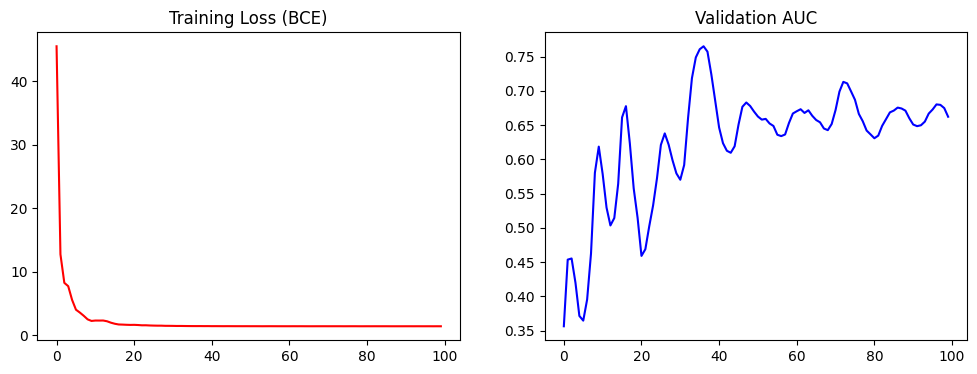

In [6]:
# Add weight_decay to explicitly prevent embedding collapse
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

def train():
    model.train()
    optimizer.zero_grad()
    
    # Get contextualized embeddings
    z = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    
    # Positive Edges (Real connections)
    pos_out = (z[graph_data.edge_index[0]] * z[graph_data.edge_index[1]]).sum(dim=-1)
    pos_loss = criterion(pos_out, torch.ones_like(pos_out))
    
    # Negative Edges (Fake connections)
    neg_edge_index = negative_sampling(
        edge_index=graph_data.edge_index, 
        num_nodes=graph_data.num_nodes,
        num_neg_samples=graph_data.edge_index.size(1)
    )
    neg_out = (z[neg_edge_index[0]] * z[neg_edge_index[1]]).sum(dim=-1)
    neg_loss = criterion(neg_out, torch.zeros_like(neg_out))
    
    loss = pos_loss + neg_loss
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test():
    model.eval()
    z = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    pos_out = (z[graph_data.edge_index[0]] * z[graph_data.edge_index[1]]).sum(dim=-1)
    neg_edge_index = negative_sampling(edge_index=graph_data.edge_index, num_nodes=graph_data.num_nodes)
    neg_out = (z[neg_edge_index[0]] * z[neg_edge_index[1]]).sum(dim=-1)
    
    y_pred = torch.cat([pos_out, neg_out]).cpu().numpy()
    y_true = torch.cat([torch.ones_like(pos_out), torch.zeros_like(neg_out)]).cpu().numpy()
    return roc_auc_score(y_true, y_pred)

print("Starting GNN Pre-training (Link Prediction)...")
losses, aucs = [],[]
for epoch in range(1, 101):
    loss = train()
    auc = test()
    losses.append(loss)
    aucs.append(auc)
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Validation AUC: {auc:.4f}')

# Plot training curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(losses, color='red'); ax[0].set_title("Training Loss (BCE)")
ax[1].plot(aucs, color='blue'); ax[1].set_title("Validation AUC")
plt.show()

## Sanity Check - no collapse

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

model.eval()
with torch.no_grad():
    final_embeddings = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr).cpu().numpy()

def get_similar_skills(query_skill, top_k=5):
    if query_skill not in skill_to_id: return[]
    query_idx = skill_to_id[query_skill]
    query_emb = final_embeddings[query_idx].reshape(1, -1)
    sims = cosine_similarity(query_emb, final_embeddings)[0]
    top_indices = sims.argsort()[-(top_k+1):][::-1][1:]
    return [(id_to_skill[idx], sims[idx]) for idx in top_indices]

# Test across distinct domains to prove it didn't collapse into one blob!
test_skills =['python', 'communication', 'nursing', 'sales', 'data analysis']

print("--- GRAPH EMBEDDING SANITY CHECK ---")
for skill in test_skills:
    if skill in skill_to_id:
        print(f"\nSkills most similar to '{skill.upper()}':")
        for s, score in get_similar_skills(skill, top_k=5):
            print(f"  -> {s} (Sim: {score:.3f})")

--- GRAPH EMBEDDING SANITY CHECK ---

Skills most similar to 'PYTHON':
  -> software development (Sim: 0.999)
  -> software engineering (Sim: 0.999)
  -> machine learning (Sim: 0.998)
  -> data science (Sim: 0.996)
  -> cloud (Sim: 0.996)

Skills most similar to 'COMMUNICATION':
  -> problem solving (Sim: 1.000)
  -> analytical skills (Sim: 0.999)
  -> problemsolving (Sim: 0.999)
  -> written communication (Sim: 0.999)
  -> negotiation (Sim: 0.999)

Skills most similar to 'NURSING':
  -> patient care (Sim: 0.999)
  -> first aid (Sim: 0.999)
  -> professional development (Sim: 0.999)
  -> volunteering (Sim: 0.999)
  -> medical terminology (Sim: 0.998)

Skills most similar to 'SALES':
  -> multitasking (Sim: 0.999)
  -> time management (Sim: 0.999)
  -> customer service (Sim: 0.999)
  -> attention to detail (Sim: 0.999)
  -> inventory management (Sim: 0.999)

Skills most similar to 'DATA ANALYSIS':
  -> excel (Sim: 0.999)
  -> reporting (Sim: 0.999)
  -> marketing (Sim: 0.999)
  -> busin

## Save

In [8]:
# Save the pre-trained weights
torch.save(model.state_dict(), '/kaggle/working/pretrained_skill_gat.pth')

# Save the final static embeddings to pass to the Transformer
np.save('/kaggle/working/skill_embeddings.npy', final_embeddings)

print(" Model and Graph Embeddings saved successfully to /kaggle/working/!")

 Model and Graph Embeddings saved successfully to /kaggle/working/!
